# 高斯混合模型 (Gaussian Mixture Model, GMM) 模拟与拟合实践

### 什么是高斯混合模型？
高斯混合模型（GMM）是一种概率模型，它假设所有的数据点都是从有限个具有未知参数的**高斯分布**（正态分布）混合生成的。
- **混合性**：它认为数据是由多个子分布组合而成的，每个子分布代表一个群组或簇。
- **软权重**：与 K-Means 的“硬分配”（一个点只能属于一个簇）不同，GMM 给出的是概率分布，即一个点属于某个簇的概率。
- **灵活性**：由于高斯分布具有协方差矩阵，GMM 可以捕捉椭圆形甚至拉伸形状的簇，而 K-Means 仅限于圆形（球形）簇。

### 为什么设计这个程序？
1. **理解生成式模型**：通过模拟生成数据，学生可以直观理解“数据是如何产生的”。
2. **掌握聚类进阶**：掌握在数据形状复杂、边界模糊时，比 K-Means 更高效的聚类方法。
3. **参数估计**：学习混合模型中均值、协方差和权重（Priors）的概念。

本项目将模拟生成一组非球形的复杂分布数据，并展示如何利用 GMM 将其准确还原出来。

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from matplotlib.patches import Ellipse
import warnings

# 1. 设置绘图风格
# 注意：必须先设置 style，再设置 rcParams，否则字体设置会被 style 覆盖
plt.style.use('seaborn-v0_8')

# 2. 解决中文显示与负号显示问题
# 设置黑体环境，如果 SimHei 不存在则尝试 Microsoft YaHei 或其他通用字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False 

# 3. 忽略不必要的警告
warnings.filterwarnings('ignore')

# 4. 设置 inline 模式
%matplotlib inline

## 1. 模拟数据生成

为了展示 GMM 处理复杂形状的能力，我们不仅生成圆形的簇，还要对数据进行**线性变换**，使其变成长条形的椭圆分布。

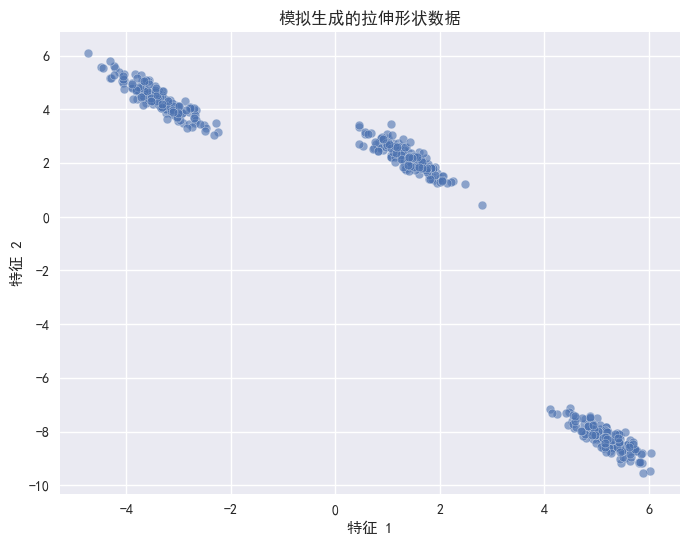

In [12]:
# 1. 生成原始的球形数据
n_samples = 500
X, y_true = make_blobs(n_samples=n_samples, centers=3, cluster_std=0.6, random_state=42)

# 2. 对数据进行拉伸变换，使其变成非球形
rng = np.random.RandomState(13)
transformation = rng.normal(size=(2, 2))
X_stretched = np.dot(X, transformation)

# 可视化原始分布
plt.figure(figsize=(8, 6))
plt.scatter(X_stretched[:, 0], X_stretched[:, 1], s=40, alpha=0.6, edgecolors='w')
plt.title("模拟生成的拉伸形状数据")
plt.xlabel("特征 1")
plt.ylabel("特征 2")
plt.show()

## 2. 构建并训练 GMM 模型

我们将尝试使用 3 个组件（Component）来拟合这些数据。GMM 会通过 **EM (期望最大化)** 算法自动迭代寻找最佳的均值和协方差矩阵。

In [13]:
# 创建 GMM 模型，设置组件数为 3
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)

# 拟合数据
gmm.fit(X_stretched)

# 预测每个点所属的簇及其概率
labels = gmm.predict(X_stretched)
probs = gmm.predict_proba(X_stretched)

print("拟合完成！")
print(f"收敛状态: {gmm.converged_}")
print(f"权重 (Weights): {gmm.weights_}")

拟合完成！
收敛状态: True
权重 (Weights): [0.334 0.332 0.334]


## 3. 结果可视化：聚类与概率

GMM 的一大特点是“软分配”。我们可以根据预测的标签对数据进行着色，并观察其拟合出的高斯分量形状。

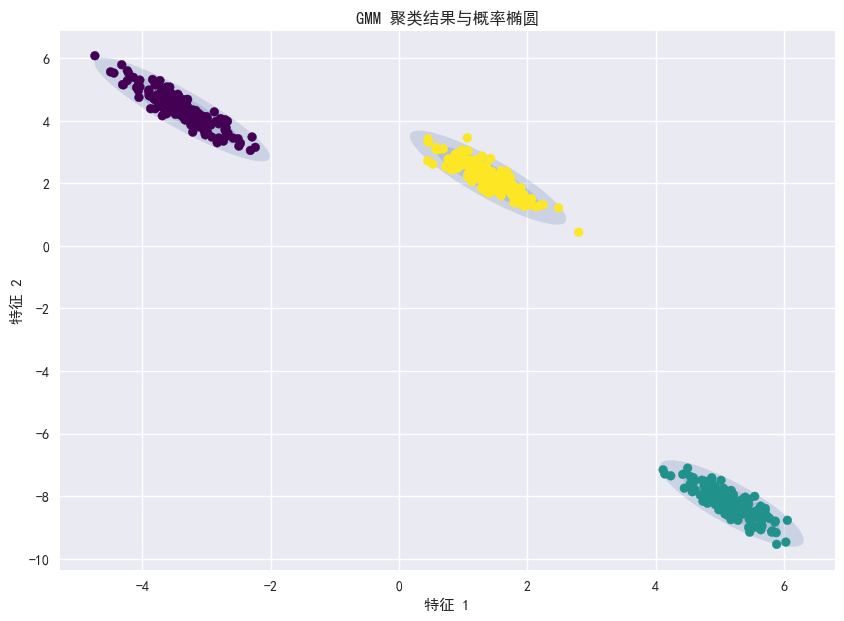

In [14]:
def draw_ellipse(position, covariance, ax=None, **kwargs):
    """绘制给定位置和协方差的高斯概率椭圆"""
    ax = ax or plt.gca()
    
    # 将协方差矩阵转换为特征值和特征向量
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    # 绘制椭圆，展示 1-3 倍标准差的覆盖范围
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle=angle, **kwargs))

plt.figure(figsize=(10, 7))
plt.scatter(X_stretched[:, 0], X_stretched[:, 1], c=labels, s=40, cmap='viridis', zorder=2)

# 绘制每个簇的中心和覆盖椭圆
w_factor = 0.2 / gmm.weights_.max()
for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
    draw_ellipse(pos, covar, alpha=w * w_factor)

plt.title("GMM 聚类结果与概率椭圆")
plt.xlabel("特征 1")
plt.ylabel("特征 2")
plt.show()

## 4. 模型评估：如何确定最佳簇数？

在实际问题中，我们往往不知道数据由多少个分量组成。通常使用 **BIC (贝叶斯信息准则)** 或 **AIC (赤池信息准则)** 来衡量模型性能，值越小通常代表模型越优。

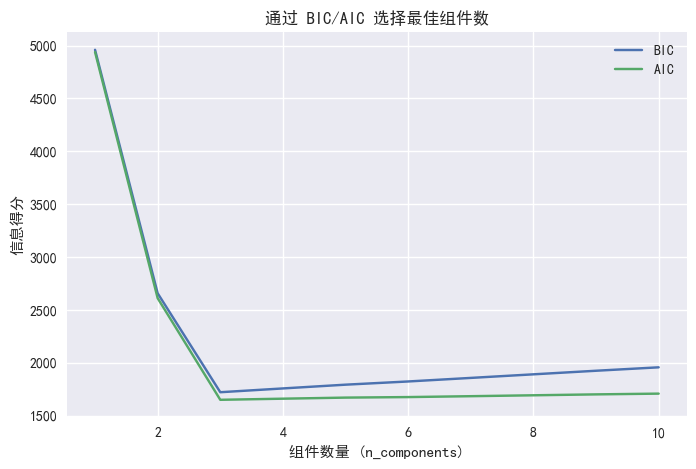

In [15]:
n_components = np.arange(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_stretched)
          for n in n_components]

plt.figure(figsize=(8, 5))
plt.plot(n_components, [m.bic(X_stretched) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X_stretched) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('组件数量 (n_components)')
plt.ylabel('信息得分')
plt.title('通过 BIC/AIC 选择最佳组件数')
plt.show()

## 10. 教学案例拓展与思考

### 思考题 1：在此模拟案例中，GMM 的表现优于 K-Means 的根本原因是什么？
- **解答思路**：K-Means 假设簇是球形的，并且只关注点到中心的欧氏距离；而 GMM 引入了**协方差矩阵**，允许簇在不同方向上有不同的延展度。本案例中的数据经过了拉伸（各向异性），因此 K-Means 会错误地强行将其切分为圆形区域。

### 思考题 2：GMM 输出的 `predict_proba` 得到的概率矩阵有什么用？
- **解答思路**：这被称为“软聚类”。在某些场景下（如病人诊断），我们不仅想知道病人属于哪一类，还想知道系统有多大把握。同时，对于处于两个簇重叠区域的“暧昧点”，概率可以帮助我们识别出潜在的离群点或多重属性数据。

### 思考题 3：如果数据的维度非常高（如 100 维），GMM 可能会面临什么问题？
- **解答思路**：**维度之灾**。在全协方差（`covariance_type='full'`）模式下，参数的数量随维度的平方级增长，容易导致过拟合且计算量剧增。可以引导学生思考尝试其他的协方差类型，如 `diag`（对角阵）或 `spherical`（球形阵）。

### 思考题 4：BIC 曲线在 3 之后趋于平缓，这意味着什么？
- **解答思路**：这反映了“惩罚项”的作用。当组件数从 1 增加到 3 时，模型对数据的拟合度显著提高，BIC 骤降。但在 3 之后，虽然拟合度可能微弱提升，但由于参数过多带来的模型复杂度惩罚开始占据主导，BIC 曲线进入平稳期甚至反弹，暗示 3 是最简洁有效的模型。